<a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-15th/blob/junmo/advanced/junmo/session03/%ED%8A%B8%EB%9E%9C%EC%8A%A4%ED%8F%AC%EB%A8%B8%EC%98%88%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### RNN의 한계
- **RNN의 한계**
  - 순차적으로 이전 단계의 정보를 다음 단계로 전달하는 구조이므로, 문장 등 데이터가 길어질수록 초반 정보가 후반부에 잘 반영되지 않는 장기 의존성 문제가 있음.
  - 학습 과정에서 가중치가 반복적으로 곱해짐에 따라 값이 0으로 사라지거나 무한대로 발산하는 기울기 소실 및 폭주 문제가 발생함.
  - 이를 극복하기 위해 게이트 구조를 도입한 모델들이 등장했으나, 연산이 복잡하고 여전히 긴 문장에서는 한계를 보임.
- **Attention의 등장 배경 및 장점**
  - 기존 모델은 입력 문장의 길이에 상관없이 모든 정보를 고정된 크기의 하나의 컨텍스트 벡터에 압축하여, 긴 문장에서는 중요한 정보가 손실되는 병목 현상이 심했음.
  - 이를 해결하기 위해 출력 단어를 생성할 때마다 입력 문장 전체를 다시 스캔하고, 현재 예측에 가장 관련 있는 부분에 높은 가중치를 부여하여 집중하는 어텐션이 등장함.
  - 거리의 제약을 받지 않고 정보를 직접 연결하여 유연성을 확보했으며, 순차 연산을 벗어나 한 번에 모든 단어의 관계를 독립적으로 계산하는 병렬 처리가 가능해짐.
- **Attention is All You Need**
  - 구글이 발표한 논문으로, 기존의 순환 구조나 합성곱 구조를 완전히 배제하고 오직 어텐션 메커니즘만으로 작동하는 트랜스포머 아키텍처를 제안함.
  - 병렬화를 통해 모델의 학습 속도를 혁신적으로 단축시켰고, 대규모 데이터를 효과적으로 다룰 수 있게 되어 현재 거대 언어 모델들의 근간이 됨.
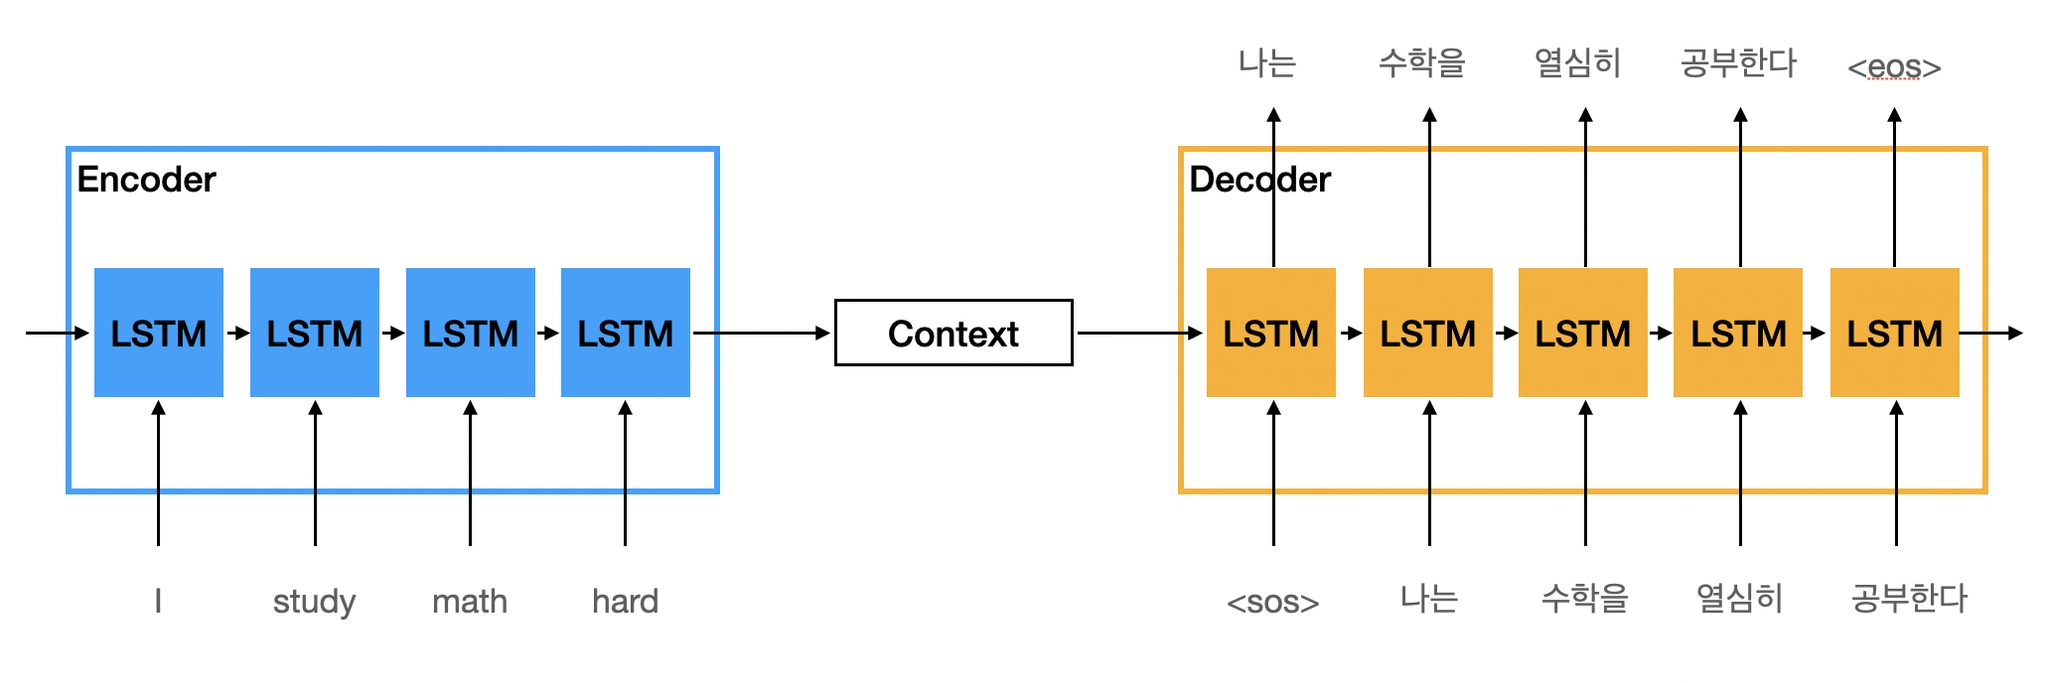
### Self-Attention
- **Query, Key, Value 개념**
  - 모델이 수많은 정보 중 가장 관련 있는 정보를 효과적으로 찾아내기 위해 역할을 세 가지로 분할한 것임.
  - **Query**: 지금 당장 알고 싶거나 초점을 맞추고 있는 기준 대상을 뜻함.
  - **Key**: 검색 대상이 되는 모든 정보들이 달고 있는 이름표 역할을 함.
  - **Value**: 키와 한 쌍으로 묶여 있는 실제 내용물로, 최종적으로 가져와 활용할 정보를 의미함.
- **Cross Attention vs. Self-Attention 개념 및 과정**
  - **Cross Attention**: 디코더가 단어를 생성할 때 인코더의 출력물을 참고하는 방식으로, 마치 오픈북 시험처럼 서로 다른 두 시퀀스를 연결하여 정보를 얻어내는 다리 역할을 함.
  - **Self-Attention**: 동일한 문장 안에서 모든 단어들끼리 서로의 관계를 직접 계산하여, 문맥과 내부 의존성(예: 대명사가 가리키는 대상 파악)을 스스로 뜯어보는 문장 성분 분석과 같음.
- **Scaled Dot-Product Attention**
  - 쿼리와 모든 키 벡터를 내적하여 각각의 유사도인 어텐션 점수를 계산함.
  - 벡터 차원이 커질수록 내적 값이 지나치게 커져 소프트맥스 함수 적용 시 특정 값에만 확률이 몰리는 기울기 소실 문제가 발생할 수 있음.
  - 이를 방지하고자 차원의 제곱근 값으로 나누어주는 스케일링 과정을 추가해 값의 분포를 안정화함.
  - 최종적으로 소프트맥스 함수를 거쳐 나온 가중치를 밸류 벡터와 곱해 조합된 새로운 벡터를 얻어냄.

### Multi-Head Attention
- **Multi-Head Attention 개념**
  - 하나의 어텐션만 사용하면 각 단어 간의 문법적, 의미적, 위치적 관계 등 다양한 정보가 단순 평균화되어 중요한 연결 고리가 희석될 수 있음.
  - 한 단어와 다른 단어 간의 관계를 여러 차원으로 쪼개어, 각기 다른 관점을 가진 여러 개의 헤드로 동시에 분석하는 방식임.
- **Multi-Head Attention 작동 방식**
  - 거대한 입력 벡터를 여러 헤드에 맞게 작은 차원으로 나눈 뒤, 각 헤드들이 서로 간섭하지 않고 독립적으로 어텐션을 병렬 계산함.
  - 이후 각 헤드가 내놓은 결과 벡터들을 하나로 다시 이어 붙이고 가중치 행렬을 한 번 더 곱해 융합함으로써, 매우 풍부하고 다각적인 문맥적 의미를 담아냄.

### Transformer 전체 아키텍처
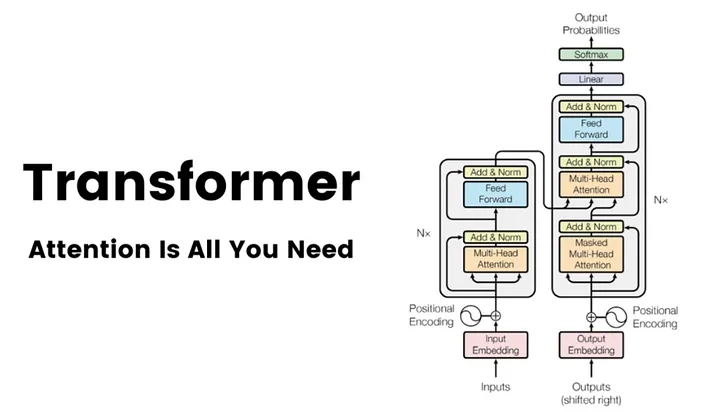
- **전처리 단계**
  - **토큰화**: 텍스트를 단어나 의미 단위 등 모델이 처리할 수 있는 기본 조각들로 분할하는 과정임.
  - **임베딩**: 분할된 단어들을 컴퓨터가 이해할 수 있는 긴 숫자 벡터로 번역함. 의미가 유사한 단어일수록 임베딩 공간에서 서로 가까운 좌표에 위치하도록 깊은 속성을 담아냄.
  - **위치 인코딩**: 병렬 처리 특성상 단어의 순서를 인식하지 못하는 모델의 약점을 보완하고자, 사인 및 코사인 함수를 통해 단어의 위치마다 일관된 규칙의 숫자 벡터를 생성하여 임베딩에 더해줌.
- **인코더**
  - 입력 문장을 한 번에 받아들여 단어들 사이의 모든 관계를 파악하고, 깊이 있는 요약 의미 벡터를 생성함.
  - **피드 포워드**: 어텐션을 거쳐 문맥이 파악된 단어 정보를 한 번 더 차원 확장과 비선형 변환을 거치게 하여 더욱 심층적으로 분석함.
  - **잔차 연결**: 신경망의 층이 깊어질 때 발생하는 기울기 소실이나 폭주를 막기 위해, 입력값을 출력에 곧바로 더해주는 지름길을 만들어 원활한 학습을 도움.
  - **층 정규화**: 입력 데이터의 스케일을 균일하게 만들어 학습의 안정성을 높이고 빠르게 정답에 수렴하게 함.
- **디코더**
  - 인코더가 파악한 의미 벡터를 넘겨받아 출력 문장의 단어를 순차적으로 하나씩 만들어냄.
  - **마스크드 멀티 헤드 어텐션**: 디코더는 단어를 생성할 때 미래에 나올 단어를 미리 엿보면 안 되므로, 현재 토큰보다 뒤에 있는 미래의 단어 정보는 0으로 가려 참조하지 못하게 강제함.
  - **인코더-디코더 어텐션**: 디코더가 지금 단어를 예측하기 위해 원본 입력 문장의 어느 부분에 높은 가중치를 두고 집중해야 할지를 인코더의 출력을 통해 확인하는 과정임.
- **전체 데이터 흐름 과정**
  - **입력 준비**: 문장을 토큰화 및 임베딩하고 위치 정보를 추가하여 의미와 순서를 모두 갖춘 입력 벡터를 준비함.
  - **문맥 파악**: 인코더가 이 벡터를 받아 셀프 어텐션을 반복하며 모든 단어 간의 복잡한 관계를 완벽히 이해한 컨텍스트 벡터 세트를 완성함.
  - **순차적 생성**: 디코더가 시작 신호를 입력받은 후, 마스크드 어텐션으로 과거 문맥을 살피고 크로스 어텐션으로 인코더의 핵심 정보와 결합하여 다음 단어를 예측하는 과정을 반복함으로써 최종 문장을 완성함.